# 1 - Entrenamiento del modelo
Transfer learning con EfficientNet-B0 preentrenado en ImageNet para clasificar 38 enfermedades en plantas.

# 2 - Imports


In [1]:
import os
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

Usando: cuda


# 3 - Transformacion de imagenes
Preparamos las imágenes para que el modelo las entienda: las redimensionamos, 
aplicamos augmentación y normalizamos con los valores estándar de ImageNet.

In [2]:
DATASET_PATH = "plantvillage dataset/color"
IMG_SIZE = 224      # tamaño estándar que espera EfficientNet
BATCH_SIZE = 32     # imágenes que procesa a la vez
NUM_CLASSES = 38    # total de enfermedades

# transformaciones para entrenamiento (con augmentación)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),        # voltea imagen horizontalmente al azar
    transforms.RandomRotation(15),            # rota hasta 15 grados al azar
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # varía brillo y contraste
    transforms.ToTensor(),                    # convierte imagen a tensor numérico
    transforms.Normalize(                     # normaliza con valores de ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# transformaciones para validación y test (sin augmentación)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformaciones definidas correctamente")

Transformaciones definidas correctamente


# 4 - DataLoaders
Dividimos el dataset en 80% entrenamiento, 10% validación y 10% test.
Luego creamos los DataLoaders que alimentan las imágenes al modelo en batches.

In [3]:
# carga todo el dataset desde la carpeta
dataset_completo = datasets.ImageFolder(root=DATASET_PATH, transform=train_transforms)

# calcula tamaños de cada split
total = len(dataset_completo)
train_size = int(0.8 * total)
validation_size = int(0.1 * total)
test_size = total - train_size - validation_size

print(f"Total imágenes:      {total:,}")
print(f"Entrenamiento:       {train_size:,}")
print(f"Validación:          {validation_size:,}")
print(f"Test:                {test_size:,}")

# divide aleatoriamente
train_dataset, val_dataset, test_dataset = random_split(
    dataset_completo,
    [train_size, validation_size, test_size],
    generator=torch.Generator().manual_seed(42)  # seed fija = resultados reproducibles
)

# aplica transformaciones de validación al val y test
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

# crea los DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nDataLoaders creados correctamente")
print(f"Clases: {dataset_completo.classes[:3]}...")

Total imágenes:      54,305
Entrenamiento:       43,444
Validación:          5,430
Test:                5,431

DataLoaders creados correctamente
Clases: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust']...


# 5 - Modelo preentrenado
Cargamos EfficientNet-B0 entrenado en ImageNet y reemplazamos 
la última capa para adaptarlo a nuestras 38 clases.

In [4]:
# carga EfficientNet-B0 con pesos preentrenados en ImageNet
modelo = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# congela todas las capas — no queremos modificar lo que ya aprendió
for param in modelo.parameters():
    param.requires_grad = False

# reemplaza la última capa por una adaptada a 38 clases
num_features = modelo.classifier[1].in_features
modelo.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, NUM_CLASSES)
)

# mueve el modelo a la GPU
modelo = modelo.to(device)

# cuenta parámetros entrenables vs congelados
entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
congelados = sum(p.numel() for p in modelo.parameters() if not p.requires_grad)

print(f"Parámetros entrenables: {entrenables:,}")
print(f"Parámetros congelados:  {congelados:,}")
print(f"\nModelo listo en: {device}")

Parámetros entrenables: 48,678
Parámetros congelados:  4,007,548

Modelo listo en: cuda


# 6 - Entrenamiento
Entrenamos solo la última capa durante 10 épocas. Guardamos el modelo 
con mejor accuracy en validación.

In [6]:
EPOCHS = 10       # número de veces que el modelo ve todo el dataset
LR = 0.001        # learning rate: qué tan grandes son los pasos al aprender

# criterio: cómo medimos el error del modelo
# CrossEntropyLoss es el estándar para clasificación multiclase
criterio = nn.CrossEntropyLoss()

# optimizador: algoritmo que ajusta los pesos para reducir el error
# solo entrenamos los parámetros del clasificador (última capa)
optimizador = optim.Adam(modelo.classifier.parameters(), lr=LR)

# guardamos las métricas de cada época para graficarlas después
historial = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

mejor_accuracy_validacion = 0.0

for epoca in range(EPOCHS):

    # -------------------------
    # FASE DE ENTRENAMIENTO
    # -------------------------
    modelo.train()  # activa capas como Dropout (se comportan distinto en train vs eval)
    perdida_entrenamiento = 0.0
    aciertos_entrenamiento = 0

    for imagenes, etiquetas in tqdm(train_loader, desc=f"Época {epoca+1}/{EPOCHS}"):

        # mueve los datos a la GPU
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        # resetea los gradientes acumulados del paso anterior
        optimizador.zero_grad()

        # pasada hacia adelante: el modelo hace sus predicciones
        predicciones = modelo(imagenes)

        # calcula el error entre predicciones y etiquetas reales
        perdida = criterio(predicciones, etiquetas)

        # pasada hacia atrás: calcula gradientes
        perdida.backward()

        # actualiza los pesos del modelo
        optimizador.step()

        # acumula métricas del batch
        perdida_entrenamiento += perdida.item()
        aciertos_entrenamiento += (predicciones.argmax(1) == etiquetas).sum().item()

    # -------------------------
    # FASE DE VALIDACIÓN
    # -------------------------
    modelo.eval()  # desactiva Dropout para evaluar con el modelo completo
    perdida_validacion = 0.0
    aciertos_validacion = 0

    with torch.no_grad():  # no calculamos gradientes, ahorramos memoria
        for imagenes, etiquetas in val_loader:

            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)

            predicciones = modelo(imagenes)
            perdida = criterio(predicciones, etiquetas)

            perdida_validacion += perdida.item()
            aciertos_validacion += (predicciones.argmax(1) == etiquetas).sum().item()

    # -------------------------
    # MÉTRICAS DE LA ÉPOCA
    # -------------------------

    # accuracy = aciertos / total de imágenes
    accuracy_entrenamiento = aciertos_entrenamiento / train_size
    accuracy_validacion = aciertos_validacion / validation_size

    # loss promedio por batch
    perdida_entrenamiento /= len(train_loader)
    perdida_validacion /= len(val_loader)

    # guarda en el historial para graficar después
    historial["train_loss"].append(perdida_entrenamiento)
    historial["val_loss"].append(perdida_validacion)
    historial["train_acc"].append(accuracy_entrenamiento)
    historial["val_acc"].append(accuracy_validacion)

    print(
        f"Época {epoca+1:02d} | "
        f"train_acc: {accuracy_entrenamiento:.4f} | "
        f"val_acc: {accuracy_validacion:.4f} | "
        f"train_loss: {perdida_entrenamiento:.4f} | "
        f"val_loss: {perdida_validacion:.4f}"
    )

    # guarda el modelo solo si mejoró respecto a la época anterior
    if accuracy_validacion > mejor_accuracy_validacion:
        mejor_accuracy_validacion = accuracy_validacion
        torch.save(modelo.state_dict(), "mejor_modelo.pth")
        print(f"           ✓ Modelo guardado (val_acc: {accuracy_validacion:.4f})")

print(f"\nEntrenamiento completado. Mejor val_acc: {mejor_accuracy_validacion:.4f}")

Época 1/10: 100%|██████████| 1358/1358 [01:28<00:00, 15.40it/s]


Época 01 | train_acc: 0.9335 | val_acc: 0.9624 | train_loss: 0.2277 | val_loss: 0.1383
           ✓ Modelo guardado (val_acc: 0.9624)


Época 2/10: 100%|██████████| 1358/1358 [01:44<00:00, 13.01it/s]


Época 02 | train_acc: 0.9446 | val_acc: 0.9670 | train_loss: 0.1850 | val_loss: 0.1218
           ✓ Modelo guardado (val_acc: 0.9670)


Época 3/10: 100%|██████████| 1358/1358 [02:15<00:00, 10.06it/s]


...

Época 08 | train_acc: 0.9538 | val_acc: 0.9698 | train_loss: 0.1374 | val_loss: 0.0959


Época 9/10: 100%|██████████| 1358/1358 [03:43<00:00,  6.07it/s]


Época 09 | train_acc: 0.9550 | val_acc: 0.9676 | train_loss: 0.1363 | val_loss: 0.0988


Época 10/10: 100%|██████████| 1358/1358 [03:42<00:00,  6.11it/s]


Época 10 | train_acc: 0.9547 | val_acc: 0.9670 | train_loss: 0.1340 | val_loss: 0.1031

Entrenamiento completado. Mejor val_acc: 0.9716


# 7 - Curvas de aprendizaje
Visualizamos cómo evolucionó el accuracy y la pérdida durante el entrenamiento.

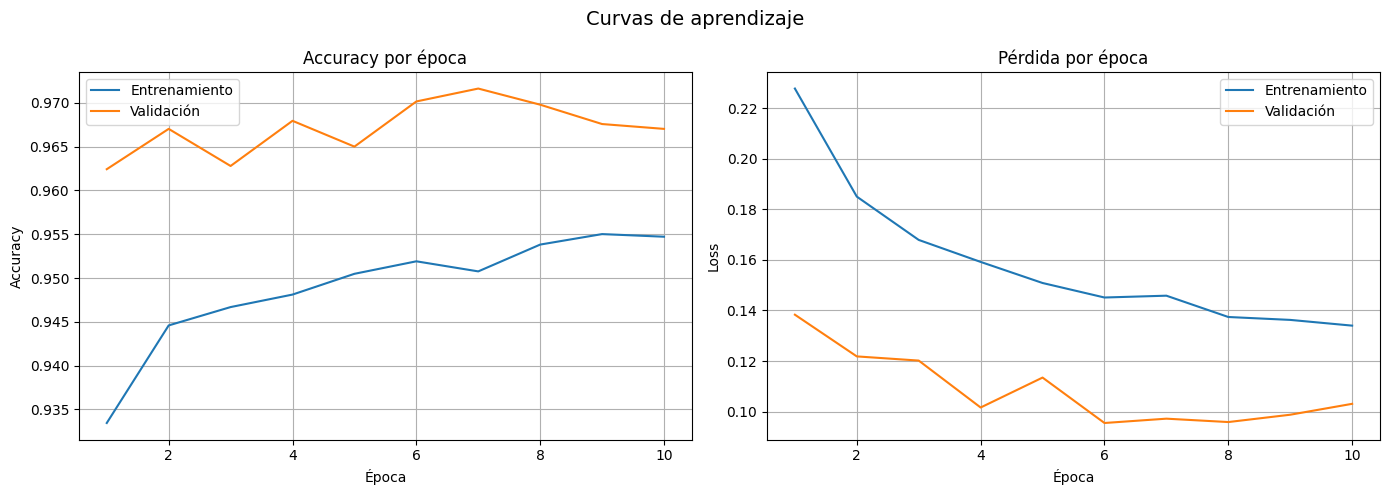

In [7]:
epocas = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# gráfica de accuracy
axes[0].plot(epocas, historial["train_acc"], label="Entrenamiento")
axes[0].plot(epocas, historial["val_acc"], label="Validación")
axes[0].set_title("Accuracy por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# gráfica de pérdida
axes[1].plot(epocas, historial["train_loss"], label="Entrenamiento")
axes[1].plot(epocas, historial["val_loss"], label="Validación")
axes[1].set_title("Pérdida por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Curvas de aprendizaje", fontsize=14)
plt.tight_layout()
plt.show()